# Lab 05 Data visualization with matplotlib and seaborn

Nice visualization libraries:
- matplotlib: https://matplotlib.org/stable/index.html
- seaborn: http://seaborn.pydata.org/
- bokeh: https://docs.bokeh.org/en/latest/
- folium (geospatial visualization): https://python-visualization.github.io/folium/latest/
- kepler.gl (large-scale geospatial visualization): https://kepler.gl/

## Please submit your finished lab05 jupyter notebook via pull request in GitHub

In [98]:
# magic command to display matplotlib plots inline within the ipython notebook webpage
%matplotlib inline

# import necessary modules
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.cm as cm, matplotlib.font_manager as fm

## load the data sets

In [99]:
# load the gps coordinate data, using the date as the full set's index
# the data files are encoded as utf-8: specify so to prevent matplotlib from choking on diacritics
df = pd.read_csv('data/summer-travel-gps-full.csv', encoding='utf-8', index_col='date', parse_dates=True)
rs = pd.read_csv('data/summer-travel-gps-dbscan.csv', encoding='utf-8')

In [100]:
df.head()

,lat,lon,city,country
date,,,,
2014-05-14 09:07:00,51.481292,-0.451011,West Drayton,United Kingdom
2014-05-14 09:22:00,51.474005,-0.450999,Hounslow,United Kingdom
2014-05-14 10:51:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:24:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:38:00,51.474146,-0.451562,Hounslow,United Kingdom


In [101]:
rs.head()

,lat,lon,date,city,country
0,51.478199,-0.446081,05/14/2014 10:51,Hounslow,United Kingdom
1,38.781775,-9.137544,05/14/2014 15:11,Lisbon,Portugal
2,38.771939,-9.128911,05/14/2014 15:41,Lisbon,Portugal
3,38.742987,-9.147780,05/14/2014 16:11,Lisbon,Portugal
4,38.693780,-9.206363,05/15/2014 14:19,Lisbon,Portugal


## First up: Bar Charts

In [102]:
!pip install seaborn

In [103]:
import seaborn as sns

C:\Users\caras\AppData\Local\Temp\ipykernel_37212\37321110.py:8: UserWarning: 
The palette list has fewer values (9) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x="country", y="count", data =country_counts, hue = "country", palette=sns.color_palette("hls", 9), legend = False)


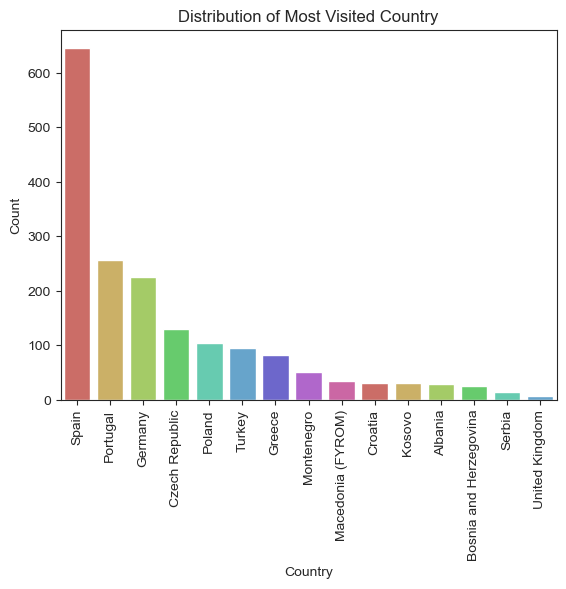

In [104]:
# Q1: Can you draw a bar chart for the most visited countries by using matplotlib and seaborn? You can use the df dataframe.
# Please style the chart to make it look nicer
# such as figsize, width, alpha, color, edgecolor, grid, xlim, and ylim
country_counts = df['country'].value_counts().reset_index()
country_counts.columns = ['country', 'count']

sns.set_style("ticks")
ax = sns.barplot(x="country", y="count", data =country_counts, hue = "country", palette=sns.color_palette("hls", 9), legend = False)
ax.set_title("Distribution of Most Visited Country")
ax.set_ylabel('Count')
ax.set_xlabel('Country')
# Here is the method to rotate the tick labels
for item in ax.get_xticklabels():
    item.set_rotation(90)

Now you try: re-create the plot above, but make the bars orange with maroon edges.

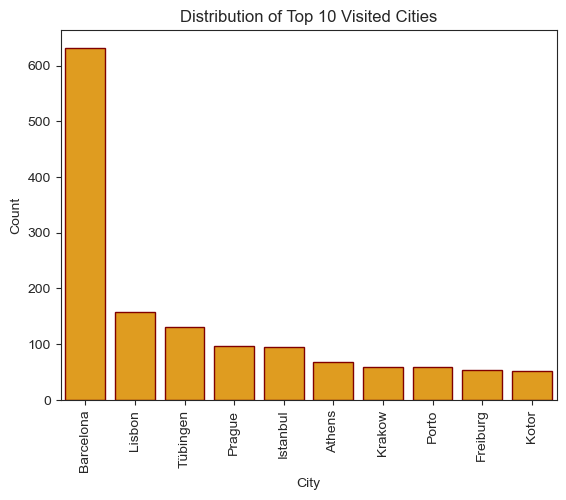

In [105]:
# Q2: Draw the same bar chart, but now for the most visited cities instead of countries
city_counts = df['city'].value_counts().reset_index()
city_counts.columns = ['city', 'count']
city_counts = city_counts.head(10)
sns.set_style("ticks")
city_plot = sns.barplot(x="city", y="count", data =city_counts, edgecolor='maroon', color='orange', legend = False)
city_plot.set_title("Distribution of Top 10 Visited Cities")
city_plot.set_ylabel('Count')
city_plot.set_xlabel('City')
# Here is the method to rotate the tick labels
for item in city_plot.get_xticklabels():
    item.set_rotation(90)

## Next: scatter plots as simple maps

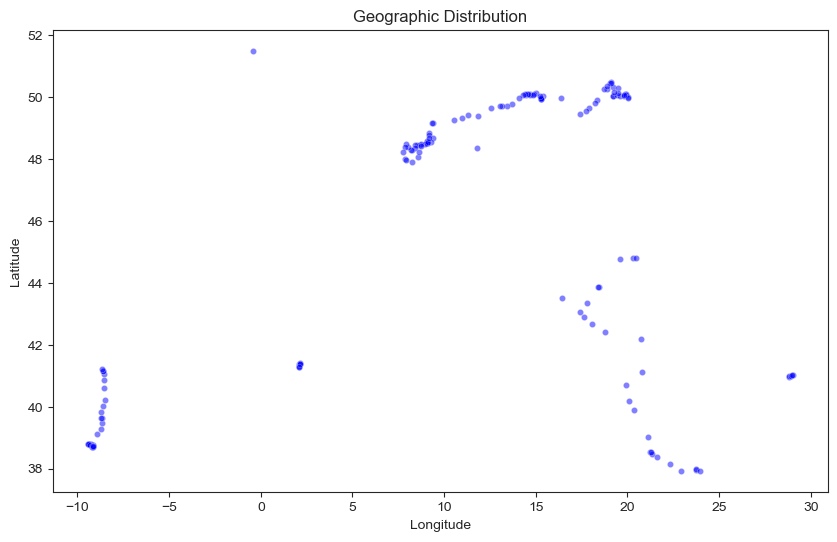

In [106]:
# Q3: Draw a scatter plot the longitude and latitude data, with matplotlib and seaborn defaults. 
# You can use the rs dataframe.
# Please style the chart to make it look nicer with good size and alpha settings. 


plt.figure(figsize=(10, 6))
sns.scatterplot(data=rs, x='lon', y='lat', color='blue', alpha=0.5, s=20)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution")
plt.show()

## Line charts, with annotation

In [107]:
# get the count of records by date
countdata = df.groupby(df.index.date).size()
countdata.head()

2014-05-14    36
2014-05-15    61
2014-05-16    57
2014-05-17    64
2014-05-18    50
dtype: int64

In [108]:
type(countdata)
for item in city_plot.get_xticklabels():
    item.set_rotation(90)

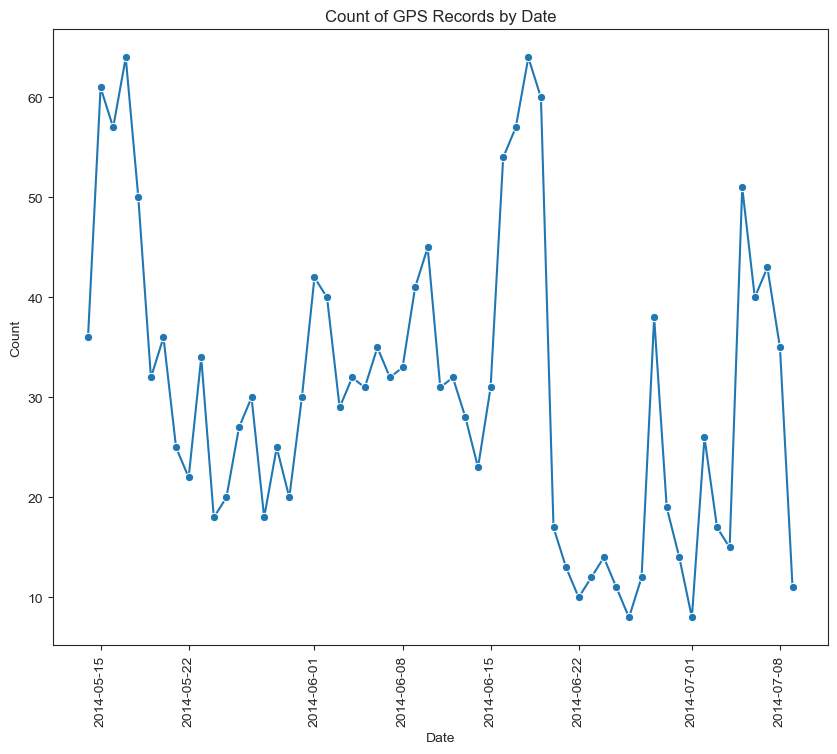

In [109]:
plt.figure(figsize=(10,8))
date_plot2 = sns.lineplot(x = countdata.index, y = countdata.values, marker = 'o')
date_plot2.set_title('Count of GPS Records by Date')
date_plot2.set_xlabel('Date')
date_plot2.set_ylabel('Count')

for i in date_plot2.get_xticklabels():
    i.set_rotation(90)

Text(0, 0.5, 'Count')

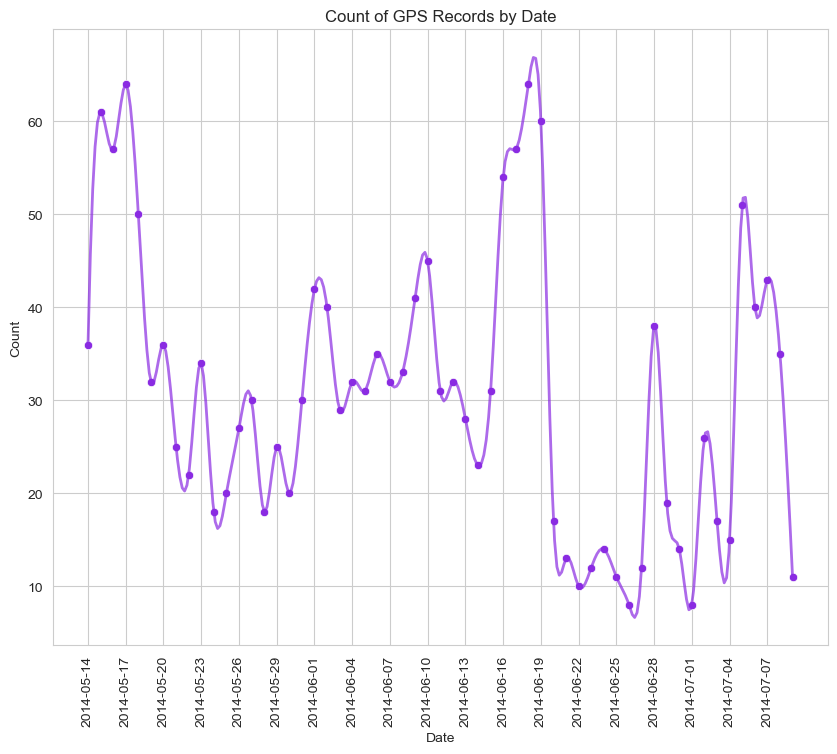

In [110]:
# Q5: Now you try: re-create the plot above with different line widths, colors, and point markers. 
# Play with moving the annotation labels around. Make the vertical tick marks 3 days apart instead of 5.
# experiment with a more advanced challenge like smoothing the line:
# - https://stackoverflow.com/questions/5283649/plot-smooth-line-with-pyplot
# - https://stackoverflow.com/questions/25825946/generating-smooth-line-graph-using-matplotlib

from scipy.interpolate import make_interp_spline, BSpline

x = np.arange(len(countdata)) #making dates into numpy array- sequence of dates for x axis
y = countdata.values # y axis as count values

#For making smooth line - generates array of evenly spaced numbers over interval of 300. k= 3 is cubic spline - creates curved line.
xnew = np.linspace(x.min(), x.max(), 300)
spl = make_interp_spline(x, y, k = 3) 
y_smooth = spl(xnew) 

#Plotting two separate figures- smoothes line plot, then scatter plot to have correct date markers (not markers of the spline)
sns.set_style('whitegrid')
plt.figure(figsize=(10,8))

date_plot = sns.lineplot(data = date_smooth, x = 'x', y = 'y', alpha = 0.7, linewidth = 2, color = 'blueviolet', marker = '')
date_plot = sns.scatterplot(x = x, y = y, color = 'blueviolet')

#Mapping tick positions back to dates, making date ticks every three days
tick_positions = range(0, len(date_count), 3)
tick_labels = date_count['Date'][::3]
plt.xticks(tick_positions, tick_labels, rotation=90)

date_plot.set_title('Count of GPS Records by Date')
date_plot.set_xlabel('Date')
date_plot.set_ylabel('Count')




## Pie charts

In [111]:
cities = df['city'].value_counts()
print(cities.count())
cities.head()



113


city
Barcelona    632
Lisbon       158
Tübingen     131
Prague        97
Istanbul      94
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of GPS Records by City')

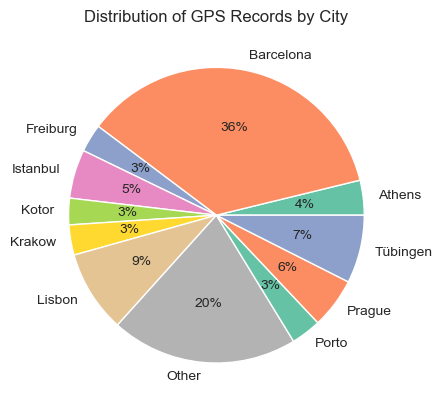

In [112]:
# Q6: draw a pie chart for cities.
# Please style the chart to make it look nicer. 
city_count = cities.to_frame(name = 'Count').reset_index()
city_count.columns = ['City', 'Count']
city_count.head()

city_top = city_count.head(10)['City']
city_count['city_grouped'] = city_count['City'].where(city_count['City'].isin(city_top), 'Other')

city_plot = city_count.groupby('city_grouped')['Count'].sum()

colour = sns.color_palette('Set2')


plt.pie(data = city_count, x = city_plot.values, colors= colour, labels = city_plot.index, autopct = '%.0f%%')
plt.title('Distribution of GPS Records by City')



## Extra task: Kepler.gl
Some examples: https://docs.kepler.gl/docs/keplergl-jupyter and https://jamesopacich.medium.com/display-a-kepler-gl-map-69d807dae082

In [113]:
# Q7: can you visualize the GPS points by using Kepler.gl? 
